#### 1. here

In [1]:
import os, glob, torch, numpy as np
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import StepLR
from PIL import Image
import torchvision.transforms.functional as TF
from collections import Counter
from concurrent.futures import ThreadPoolExecutor, as_completed
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import time

DATA_ROOT = "./mura_downloads"
CLASSES   = ["ELBOW","FINGER","FOREARM","HAND","HUMERUS","SHOULDER","WRIST"]
CLASS2IDX = {c: i for i, c in enumerate(CLASSES)}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

def collect_paths_labels(split):
    paths, labels = [], []
    for cls in CLASSES:
        pattern = os.path.join(DATA_ROOT, split, f"XR_{cls}", "**", "*.png")
        for p in glob.glob(pattern, recursive=True):
            paths.append(p); labels.append(CLASS2IDX[cls])
    return paths, labels

tr_paths, tr_labels = collect_paths_labels("train")
va_paths, va_labels = collect_paths_labels("valid")
print(f"Train {len(tr_paths)}, Valid {len(va_paths)}")
for c in CLASSES:
    print(f"  {c:10s}: {tr_labels.count(CLASS2IDX[c])}")

Device: cpu
Train 36808, Valid 3197
  ELBOW     : 4931
  FINGER    : 5106
  FOREARM   : 1825
  HAND      : 5543
  HUMERUS   : 1272
  SHOULDER  : 8379
  WRIST     : 9752


In [2]:
# Circular-mask filter disabled: use raw dataset as-is (no filtering)
print(f"Train {len(tr_paths):,}, Valid {len(va_paths):,} (no filter, raw dataset)")
for c in CLASSES:
    print(f"  {c:10s}: train {tr_labels.count(CLASS2IDX[c]):>5}, valid {va_labels.count(CLASS2IDX[c]):>4}")

Train 36,808, Valid 3,197 (no filter, raw dataset)
  ELBOW     : train  4931, valid  465
  FINGER    : train  5106, valid  461
  FOREARM   : train  1825, valid  301
  HAND      : train  5543, valid  460
  HUMERUS   : train  1272, valid  288
  SHOULDER  : train  8379, valid  563
  WRIST     : train  9752, valid  659


In [3]:
IMG_SIZE    = 224
CHUNK_W     = 4
GRID_ROWS   = 224   # IMG_SIZE
GRID_COLS   = 56    # IMG_SIZE // CHUNK_W
NUM_SCALARS = 2
BATCH_SIZE  = 64
NUM_EPOCHS  = 30
LR          = 1e-3
SEED        = 42
MODEL_PATH  = "./mura_sparsity_classifier.pth"

# XOR cache 공통 상수 (모든 ref config에서 공유)
XOR_ROWS    = GRID_ROWS   # 224
XOR_COLS    = GRID_COLS   # 56
CHUNK_BYTES = 16          # 4 float32 × 4 bytes

def _make_ref_chunk(u8_val):
    f32 = np.array([u8_val], dtype=np.float32) / np.float32(255)
    return np.tile(f32.view(np.uint8), 4)   # (16,) bytes

torch.manual_seed(SEED)

print(f"Resize       : {IMG_SIZE}×{IMG_SIZE}  (aspect ratio ignored, DenseNet-MURA-PyTorch style)")
print(f"Sparsity grid: {GRID_ROWS}×{GRID_COLS} (chunk_w={CHUNK_W})")
print(f"Sparse cond  : all 4 float32 pixels == 0.0 (16 bytes = 0x00)")
print(f"Model input  : (1, {GRID_ROWS}, {GRID_COLS})")
print(f"XOR_ROWS={XOR_ROWS}  XOR_COLS={XOR_COLS}  CHUNK_BYTES={CHUNK_BYTES}")

Resize       : 224×224  (aspect ratio ignored, DenseNet-MURA-PyTorch style)
Sparsity grid: 224×56 (chunk_w=4)
Sparse cond  : all 4 float32 pixels == 0.0 (16 bytes = 0x00)
Model input  : (1, 224, 56)
XOR_ROWS=224  XOR_COLS=56  CHUNK_BYTES=16


In [4]:
def compute_sparsity_map(arr_f32):
    """arr_f32: float32 (IMG_SIZE, IMG_SIZE), values in [0.0, 1.0].
    All 4 pixels == 0.0 → sparse (white) = all 16 bytes are 0x00.
    """
    chunks = arr_f32.reshape(GRID_ROWS, GRID_COLS, CHUNK_W)
    return (chunks == 0.0).all(axis=2).astype(np.float32)


class SparsityDataset(Dataset):
    def __init__(self, paths, labels):
        self.image_paths = paths
        self.labels      = labels

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('L')
        orig_w, orig_h = img.size

        # DenseNet-MURA-PyTorch style: resize to 224×224 ignoring aspect ratio
        resized = img.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
        arr = np.array(resized, dtype=np.float32) / 255.0  # float32 [0, 1]
        sp_map = compute_sparsity_map(arr)                  # (224, 56)
        tensor = torch.from_numpy(sp_map).unsqueeze(0)     # (1, 224, 56)

        scalars = torch.tensor([
            float(sp_map.mean()),                           # sparsity ratio
            orig_h / orig_w if orig_w > 0 else 1.0,        # orig aspect H/W
        ], dtype=torch.float32)

        return tensor, scalars, self.labels[idx]


train_dataset = SparsityDataset(tr_paths, tr_labels)
valid_dataset = SparsityDataset(va_paths, va_labels)

inp, sc, lbl = train_dataset[0]
print(f"Input shape : {tuple(inp.shape)}")
print(f"Scalars     : sparsity={sc[0]:.3f}  orig_aspect={sc[1]:.3f}")
print(f"Label       : {lbl} ({CLASSES[lbl]})")

Input shape : (1, 224, 56)
Scalars     : sparsity=0.000  orig_aspect=1.261
Label       : 0 (ELBOW)


In [5]:
label_counts = Counter(train_dataset.labels)
total = len(train_dataset)
class_weights = torch.tensor(
    [total / (len(CLASSES) * label_counts[i]) for i in range(len(CLASSES))],
    dtype=torch.float32
).to(device)

print("Class weights (inverse frequency):")
for i, c in enumerate(CLASSES):
    print(f"  {c:10s}  count={label_counts[i]:>6}  weight={class_weights[i]:.3f}")

loader_kw = dict(batch_size=BATCH_SIZE, num_workers=4,
                 persistent_workers=False, pin_memory=False)
train_loader = DataLoader(train_dataset, shuffle=True,  **loader_kw)
valid_loader = DataLoader(valid_dataset, shuffle=False, **loader_kw)
print(f"\nTrain batches: {len(train_loader)}, Valid batches: {len(valid_loader)}")

Class weights (inverse frequency):
  ELBOW       count=  4931  weight=1.066
  FINGER      count=  5106  weight=1.030
  FOREARM     count=  1825  weight=2.881
  HAND        count=  5543  weight=0.949
  HUMERUS     count=  1272  weight=4.134
  SHOULDER    count=  8379  weight=0.628
  WRIST       count=  9752  weight=0.539

Train batches: 576, Valid batches: 50


In [6]:
class XorSliceCachedDataset(Dataset):
    """Index-only from memmap — near-zero __getitem__ cost, no GPU idle."""
    def __init__(self, slices_mm, aspects, labels, augment=False):
        self.slices  = slices_mm   # (N, n_ref, 224, 56) bool memmap
        self.aspects = aspects     # (N,) float32
        self.labels  = labels
        self.augment = augment

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        slices = self.slices[idx].astype(np.float32)   # bool → float32
        if self.augment:
            flip   = (np.random.random(slices.shape) < 0.005).astype(np.float32)
            slices = np.abs(slices - flip)
        tensor = torch.from_numpy(slices)
        aspect = torch.tensor([self.aspects[idx]], dtype=torch.float32)
        return tensor, aspect, self.labels[idx]

print("XorSliceCachedDataset defined")

XorSliceCachedDataset defined


In [7]:
import torch.nn.functional as F

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.c1   = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.b1   = nn.BatchNorm2d(out_ch)
        self.c2   = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.b2   = nn.BatchNorm2d(out_ch)
        self.down = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
            nn.BatchNorm2d(out_ch),
        ) if (stride != 1 or in_ch != out_ch) else nn.Identity()

    def forward(self, x):
        return F.relu(self.b2(self.c2(F.relu(self.b1(self.c1(x))))) + self.down(x))


class XorSliceResNet(nn.Module):
    """
    Input : (B, n_ref, 224, 56)  — strict-XOR reference slices
    Scalar: (B, 1)                — orig aspect ratio h/w
    Stem stride (2,1): 224→112 rows, 56 cols preserved
    MaxPool (2,1)   : 112→56  → 56×56 square → stride-2 ResBlocks
    """
    def __init__(self, num_classes=7, n_ref=16):
        super().__init__()
        self.stem   = nn.Sequential(
            nn.Conv2d(n_ref, 32, kernel_size=(7, 3), stride=(2, 1),
                      padding=(3, 1), bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
        )
        self.pool1  = nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1))
        self.layer1 = ResBlock(32,  64,  stride=1)
        self.layer2 = ResBlock(64,  128, stride=2)
        self.layer3 = ResBlock(128, 256, stride=2)
        self.layer4 = ResBlock(256, 512, stride=2)
        self.gap    = nn.AdaptiveAvgPool2d(1)
        self.head   = nn.Sequential(
            nn.Linear(512 + 1, 256), nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes),
        )

    def forward(self, x, sc):
        x = self.pool1(self.stem(x))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.gap(x).flatten(1)
        return self.head(torch.cat([x, sc], dim=1))


print("ResBlock / XorSliceResNet defined")

ResBlock / XorSliceResNet defined


In [8]:
# ── Density survey: XOR hit rate for all 256 u8 values on training set ────────
# 36808장 스캔. 이미 있으면 로드만 함.
# 메모리: 이미지당 12544×256×16 ≈ 49 MB (병렬 16 worker → 피크 ~800 MB)
import numpy as np
DENSITY_SURVEY_PATH = "./xor_density_survey.npy"

_ALL256_CHUNKS = np.array([_make_ref_chunk(v) for v in range(256)], dtype=np.uint8)  # (256, 16)

def _survey_one(path):
    arr_f32 = np.array(Image.open(path).convert("L").resize((224, 224), Image.BILINEAR),
                       dtype=np.float32) / np.float32(255)
    chunks = arr_f32.flatten().view(np.uint8).reshape(XOR_ROWS * XOR_COLS, CHUNK_BYTES)
    xor = chunks[:, np.newaxis, :] ^ _ALL256_CHUNKS[np.newaxis, :, :]  # (12544, 256, 16)
    return (xor == 0).all(axis=2).sum(axis=0).astype(np.int32)         # (256,)

if not os.path.exists(DENSITY_SURVEY_PATH):
    print(f"Scanning {len(tr_paths):,} images for all-256 XOR density survey...")
    t0 = time.time()
    _hit = np.zeros(256, dtype=np.int64)
    WORKERS = min(16, os.cpu_count() or 8)
    done = 0
    with ThreadPoolExecutor(max_workers=WORKERS) as ex:
        for cnt in ex.map(_survey_one, tr_paths):
            _hit += cnt
            done += 1
            if done % 5000 == 0:
                print(f"  {done:>6}/{len(tr_paths)}  {time.time()-t0:.0f}s")
    np.save(DENSITY_SURVEY_PATH, _hit)
    print(f"Saved → {DENSITY_SURVEY_PATH}  ({time.time()-t0:.0f}s)")
else:
    _hit = np.load(DENSITY_SURVEY_PATH)
    print(f"Loaded: {DENSITY_SURVEY_PATH}")

_n_chunks_total = len(tr_paths) * XOR_ROWS * XOR_COLS
_density_all256 = _hit / _n_chunks_total
_ranked         = np.argsort(-_density_all256)          # u8 index sorted by density desc

print(f"\n{'rank':>5}  {'u8':>4}  {'density':>10}  {'hits':>14}")
print("-" * 44)
for rank, u8 in enumerate(_ranked[:40].tolist(), 1):
    print(f"{rank:>5}  {u8:>4d}  {_density_all256[u8]:>10.6f}  {_hit[u8]:>14,}")

Loaded: ./xor_density_survey.npy

 rank    u8     density            hits
--------------------------------------------
    1     0    0.055879      25,800,460
    2     4    0.015728       7,261,962
    3     1    0.013412       6,192,463
    4     3    0.012461       5,753,504
    5     2    0.007999       3,693,081
    6     5    0.006639       3,065,401
    7    29    0.005551       2,562,921
    8    30    0.005227       2,413,342
    9    35    0.004975       2,297,279
   10    32    0.004925       2,273,842
   11    34    0.004805       2,218,704
   12    33    0.004667       2,154,739
   13    31    0.004621       2,133,603
   14    38    0.004620       2,133,160
   15    10    0.004546       2,099,183
   16    28    0.004468       2,062,773
   17     9    0.003932       1,815,425
   18    36    0.003893       1,797,308
   19    27    0.003606       1,665,016
   20    11    0.003473       1,603,448
   21     8    0.003232       1,492,391
   22    37    0.002992       1,381,655
 

In [9]:
# ── ref 값 선택: top-N by XOR density (nested: [:16] ⊂ [:32] ⊂ [:64]) ─────────
# density survey 결과를 기반으로 REF_U8_16/32/64 정의.
# 캐시(xor_cache_16, xor_cache_64)가 이미 있고 ref가 바뀌면 삭제 후 재빌드 필요.
_ranked_list = _ranked.tolist()

REF_U8_16 = _ranked_list[:16]
REF_U8_32 = _ranked_list[:32]
REF_U8_64 = _ranked_list[:64]
N_REF_16, N_REF_32, N_REF_64 = 16, 32, 64

print("REF_U8_16:", REF_U8_16)
print("REF_U8_32:", REF_U8_32)
print("REF_U8_64:", REF_U8_64)
assert REF_U8_32[:16] == REF_U8_16, "nested [:16] broken"
assert REF_U8_64[:32] == REF_U8_32, "nested [:32] broken"
print("\nnested ✓  (top-16 ⊂ top-32 ⊂ top-64 by XOR density)")
print()
print("density by rank:")
for i, u8 in enumerate(REF_U8_64):
    marker = " ←16" if i < 16 else (" ←32" if i < 32 else "")
    print(f"  [{i+1:2d}] u8={u8:>3d}  density={_density_all256[u8]:.6f}{marker}")

REF_U8_16: [0, 4, 1, 3, 2, 5, 29, 30, 35, 32, 34, 33, 31, 38, 10, 28]
REF_U8_32: [0, 4, 1, 3, 2, 5, 29, 30, 35, 32, 34, 33, 31, 38, 10, 28, 9, 36, 27, 11, 8, 37, 6, 7, 26, 39, 50, 40, 25, 57, 41, 42]
REF_U8_64: [0, 4, 1, 3, 2, 5, 29, 30, 35, 32, 34, 33, 31, 38, 10, 28, 9, 36, 27, 11, 8, 37, 6, 7, 26, 39, 50, 40, 25, 57, 41, 42, 58, 56, 43, 24, 55, 44, 59, 54, 45, 53, 52, 205, 23, 46, 47, 51, 49, 60, 22, 48, 12, 21, 61, 62, 20, 63, 16, 64, 13, 65, 19, 66]

nested ✓  (top-16 ⊂ top-32 ⊂ top-64 by XOR density)

density by rank:
  [ 1] u8=  0  density=0.055879 ←16
  [ 2] u8=  4  density=0.015728 ←16
  [ 3] u8=  1  density=0.013412 ←16
  [ 4] u8=  3  density=0.012461 ←16
  [ 5] u8=  2  density=0.007999 ←16
  [ 6] u8=  5  density=0.006639 ←16
  [ 7] u8= 29  density=0.005551 ←16
  [ 8] u8= 30  density=0.005227 ←16
  [ 9] u8= 35  density=0.004975 ←16
  [10] u8= 32  density=0.004925 ←16
  [11] u8= 34  density=0.004805 ←16
  [12] u8= 33  density=0.004667 ←16
  [13] u8= 31  density=0.004621 ←16
  

# ref 선택 결과 & 16-ref 캐시/학습

In [ ]:
# REF_U8_16, N_REF_16 은 density survey 셀에서 정의됨 (top-16 by XOR density)
REF_CHUNKS_16 = np.array([_make_ref_chunk(k) for k in REF_U8_16], dtype=np.uint8)  # (16, 16)

def compute_xor_slices_16(path):
    """Returns (N_REF_16, 224, 56) float32 — strict XOR match per reference page."""
    img     = Image.open(path).convert("L")
    arr_f32 = np.array(img.resize((224, 224), Image.BILINEAR),
                       dtype=np.float32) / np.float32(255)
    chunks  = arr_f32.flatten().view(np.uint8).reshape(XOR_ROWS, XOR_COLS, CHUNK_BYTES)
    xor     = chunks[np.newaxis] ^ REF_CHUNKS_16[:, np.newaxis, np.newaxis, :]
    return (xor == 0).all(axis=3).astype(np.float32)   # (16, 224, 56)

# sanity check
_sl16 = compute_xor_slices_16(tr_paths[0])
print(f"slice shape : {_sl16.shape}  dtype={_sl16.dtype}")
print(f"{'rank':>5}  {'ref u8':>6}  {'density':>10}")
for i, k in enumerate(REF_U8_16):
    print(f"{i+1:>5}  {k:>6d}  {_sl16[i].mean():>10.6f}")

In [ ]:
# ── Pre-compute & cache XOR slices for 16 ref pages (one-time) ──────────────
CACHE_DIR_16       = "./xor_cache_16"
TR_SLICES_16_PATH  = os.path.join(CACHE_DIR_16, "tr_slices.npy")
TR_ASPECTS_16_PATH = os.path.join(CACHE_DIR_16, "tr_aspects.npy")
VA_SLICES_16_PATH  = os.path.join(CACHE_DIR_16, "va_slices.npy")
VA_ASPECTS_16_PATH = os.path.join(CACHE_DIR_16, "va_aspects.npy")
os.makedirs(CACHE_DIR_16, exist_ok=True)

def _compute_one_16(path):
    img = Image.open(path).convert("L")
    orig_w, orig_h = img.size
    arr_f32 = np.array(img.resize((224, 224), Image.BILINEAR),
                       dtype=np.float32) / np.float32(255)
    flat   = arr_f32.flatten().view(np.uint8)
    chunks = flat.reshape(XOR_ROWS, XOR_COLS, CHUNK_BYTES)
    xor    = chunks[np.newaxis] ^ REF_CHUNKS_16[:, np.newaxis, np.newaxis, :]
    slices = (xor == 0).all(axis=3)       # (16, 224, 56) bool
    aspect = np.float32(orig_h / max(orig_w, 1))
    return slices, aspect

def build_cache_16(paths, slices_path, aspects_path, tag=""):
    n       = len(paths)
    mm      = np.lib.format.open_memmap(slices_path, mode='w+',
                                         dtype=bool, shape=(n, N_REF_16, XOR_ROWS, XOR_COLS))
    aspects = np.zeros(n, dtype=np.float32)
    WORKERS = min(16, os.cpu_count() or 8)
    t0 = time.time()
    with ThreadPoolExecutor(max_workers=WORKERS) as ex:
        futs = {ex.submit(_compute_one_16, p): i for i, p in enumerate(paths)}
        done = 0
        for fut in as_completed(futs):
            i = futs[fut]
            mm[i], aspects[i] = fut.result()
            done += 1
            if done % 5000 == 0:
                elapsed = time.time() - t0
                print(f"  [{tag}] {done:>6}/{n}  {elapsed:.0f}s")
    np.save(aspects_path, aspects)
    size_gb = os.path.getsize(slices_path) / 1e9
    print(f"  [{tag}] done → {slices_path} ({size_gb:.1f} GB)  {time.time()-t0:.0f}s")
    return mm, aspects

if not os.path.exists(TR_SLICES_16_PATH):
    print(f"Building train cache ({len(tr_paths):,} images)...")
    tr_slices16_mm, tr_aspects16 = build_cache_16(tr_paths, TR_SLICES_16_PATH, TR_ASPECTS_16_PATH, "train")
else:
    print("Loading train cache (memmap)...")
    tr_slices16_mm = np.lib.format.open_memmap(TR_SLICES_16_PATH, mode='r')
    tr_aspects16   = np.load(TR_ASPECTS_16_PATH)

if not os.path.exists(VA_SLICES_16_PATH):
    print(f"Building valid cache ({len(va_paths):,} images)...")
    va_slices16_mm, va_aspects16 = build_cache_16(va_paths, VA_SLICES_16_PATH, VA_ASPECTS_16_PATH, "valid")
else:
    print("Loading valid cache (memmap)...")
    va_slices16_mm = np.lib.format.open_memmap(VA_SLICES_16_PATH, mode='r')
    va_aspects16   = np.load(VA_ASPECTS_16_PATH)

print(f"\nTrain: {tr_slices16_mm.shape}  aspects: {tr_aspects16.shape}")
print(f"Valid: {va_slices16_mm.shape}  aspects: {va_aspects16.shape}")

In [ ]:
BATCH_XOR_16      = 128
XOR_16_MODEL_PATH = "./mura_xor_slice_16ref.pth"

xor16_tr_ds = XorSliceCachedDataset(tr_slices16_mm, tr_aspects16, tr_labels, augment=True)
xor16_va_ds = XorSliceCachedDataset(va_slices16_mm, va_aspects16, va_labels, augment=False)
xor16_tr_ld = DataLoader(xor16_tr_ds, batch_size=BATCH_XOR_16, shuffle=True,
                         num_workers=8, pin_memory=True, persistent_workers=True)
xor16_va_ld = DataLoader(xor16_va_ds, batch_size=BATCH_XOR_16, shuffle=False,
                         num_workers=4, pin_memory=True, persistent_workers=True)
print(f"Train: {len(xor16_tr_ds):,}  Valid: {len(xor16_va_ds):,}")
print(f"Train batches: {len(xor16_tr_ld)}  Valid batches: {len(xor16_va_ld)}")
t, a, l = xor16_tr_ds[0]
print(f"item0: tensor={tuple(t.shape)}  aspect={a.item():.3f}  label={l}({CLASSES[l]})")

In [ ]:
xor16_model = XorSliceResNet(len(CLASSES), n_ref=N_REF_16).to(device)
n_params16  = sum(p.numel() for p in xor16_model.parameters())
print(f"XorSliceResNet (16-ref): {n_params16:,} parameters")
with torch.no_grad():
    _x16  = torch.zeros(2, N_REF_16, 224, 56).to(device)
    _sc16 = torch.zeros(2, 1).to(device)
    print(f"Output shape  : {tuple(xor16_model(_x16, _sc16).shape)}  (expected (2, {len(CLASSES)}))")

## ⚠️ 모델 학습 셀 — v2 (16-ref)
이 셀은 **모델 학습 셀**입니다. 실행하면 XorSliceResNet (16-ref) 학습이 시작됩니다.

- epochs: 50, batch: 128
- 저장: `mura_xor_slice_16ref.pth` (best val 기준)
- 사전 필요: xor_cache_16/ 빌드 완료 (cell `c2e742b1`)

In [ ]:

EPOCHS_XOR_16 = 50

counts_xor16 = np.bincount(tr_labels, minlength=len(CLASSES))
w_xor16 = torch.tensor(
    counts_xor16.sum() / (len(CLASSES) * counts_xor16), dtype=torch.float32
).to(device)

crit_xor16  = nn.CrossEntropyLoss(weight=w_xor16, label_smoothing=0.1)
optim_xor16 = optim.AdamW(xor16_model.parameters(), lr=3e-4, weight_decay=1e-4)
sched_xor16 = optim.lr_scheduler.CosineAnnealingLR(optim_xor16, T_max=EPOCHS_XOR_16)

best_xor16 = 0.0
for epoch in range(1, EPOCHS_XOR_16 + 1):
    t0 = time.time()
    xor16_model.train()
    tr_loss, tr_correct, tr_total = 0., 0, 0
    for imgs, sc, lbl in xor16_tr_ld:
        imgs, sc, lbl = imgs.to(device), sc.to(device), lbl.to(device)
        optim_xor16.zero_grad()
        out  = xor16_model(imgs, sc)
        loss = crit_xor16(out, lbl)
        loss.backward(); optim_xor16.step()
        tr_loss    += loss.item() * imgs.size(0)
        tr_correct += out.argmax(1).eq(lbl).sum().item()
        tr_total   += imgs.size(0)
    sched_xor16.step()

    xor16_model.eval()
    va_loss, va_correct, va_total = 0., 0, 0
    with torch.no_grad():
        for imgs, sc, lbl in xor16_va_ld:
            imgs, sc, lbl = imgs.to(device), sc.to(device), lbl.to(device)
            out = xor16_model(imgs, sc)
            va_loss    += crit_xor16(out, lbl).item() * imgs.size(0)
            va_correct += out.argmax(1).eq(lbl).sum().item()
            va_total   += imgs.size(0)
    va_acc = 100. * va_correct / va_total
    tag = ""
    if va_acc > best_xor16:
        best_xor16 = va_acc
        torch.save(xor16_model.state_dict(), XOR_16_MODEL_PATH)
        tag = " ← saved"
    print(f"[{epoch:2d}/{EPOCHS_XOR_16}]  "
          f"tr {tr_loss/tr_total:.4f}/{100.*tr_correct/tr_total:.1f}%  "
          f"va {va_loss/va_total:.4f}/{va_acc:.1f}%  "
          f"{time.time()-t0:.0f}s{tag}")

print(f"\nBest val: {best_xor16:.1f}%")

In [ ]:
# ── 16-ref 추론 (학습 셀 건너뛰어도 독립 실행 가능) ──────────────────────────
XOR_16_MODEL_PATH = "./mura_xor_slice_16ref.pth"
if not os.path.exists(XOR_16_MODEL_PATH):
    raise FileNotFoundError(
        f"{XOR_16_MODEL_PATH} not found — 학습 셀(⚠️ v2 16-ref)을 먼저 실행하거나 pth 파일을 복사하세요"
    )

# 모델 새로 생성 후 best weights 로드 (학습 셀 의존 없음)
_m16 = XorSliceResNet(len(CLASSES), n_ref=N_REF_16).to(device)
_m16.load_state_dict(torch.load(XOR_16_MODEL_PATH, map_location=device, weights_only=True))
_m16.eval()

# val DataLoader 생성 (캐시 셀이 실행됐으면 va_slices16_mm 사용 가능)
_va16_ds = XorSliceCachedDataset(va_slices16_mm, va_aspects16, va_labels, augment=False)
_va16_ld = DataLoader(_va16_ds, batch_size=128, shuffle=False,
                      num_workers=4, pin_memory=False)

preds_xor16, trues_xor16 = [], []
with torch.no_grad():
    for imgs, sc, lbl in _va16_ld:
        preds_xor16.extend(_m16(imgs.to(device), sc.to(device)).argmax(1).cpu().numpy())
        trues_xor16.extend(lbl.numpy())
preds_xor16 = np.array(preds_xor16)
trues_xor16 = np.array(trues_xor16)

print(classification_report(trues_xor16, preds_xor16, target_names=CLASSES))
print("Per-class accuracy:")
for i, c in enumerate(CLASSES):
    m = trues_xor16 == i
    print(f"  {c:10s}: {(preds_xor16[m]==i).mean()*100:.1f}%  ({m.sum()} samples)")

cm16 = confusion_matrix(trues_xor16, preds_xor16)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm16, cmap='Blues')
fig.colorbar(im, ax=ax)
ax.set(xticks=range(7), yticks=range(7), xticklabels=CLASSES, yticklabels=CLASSES,
       ylabel='True', xlabel='Predicted',
       title='XorSliceResNet — 16 ref pages, strict XOR')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
thresh = cm16.max() / 2
for i in range(7):
    for j in range(7):
        ax.text(j, i, cm16[i, j], ha='center', va='center',
                color='white' if cm16[i, j] > thresh else 'black')
plt.tight_layout()
plt.savefig("mura_xor16_confusion_matrix.pdf", format='pdf', bbox_inches='tight')
plt.show()

# v3 (32 / 64-ref) — density-based nested cache

- REF_U8_64 = top-64 by XOR density (survey 셀에서 정의)
- nested: `[:16]`=REF_U8_16, `[:32]`=REF_U8_32 — **64-ref 캐시 하나로 모두 커버**
- ref가 바뀌면 `xor_cache_64/` 삭제 후 재빌드 필요

#### here the first cell

In [10]:
# REF_U8_64, N_REF_64 은 density survey 셀에서 정의됨
# nested: REF_U8_64[:16] == REF_U8_16, REF_U8_64[:32] == REF_U8_32
REF_CHUNKS_64 = np.array([_make_ref_chunk(k) for k in REF_U8_64], dtype=np.uint8)  # (64, 16)

def compute_xor_slices_64(path):
    """Returns (N_REF_64, 224, 56) float32 — strict XOR match per reference page."""
    arr_f32 = np.array(Image.open(path).convert("L").resize((224, 224), Image.BILINEAR),
                       dtype=np.float32) / np.float32(255)
    chunks  = arr_f32.flatten().view(np.uint8).reshape(XOR_ROWS, XOR_COLS, CHUNK_BYTES)
    xor     = chunks[np.newaxis] ^ REF_CHUNKS_64[:, np.newaxis, np.newaxis, :]
    return (xor == 0).all(axis=3).astype(np.float32)

print(f"N_REF_64={N_REF_64}  N_REF_32={N_REF_32}  N_REF_16={N_REF_16}")
print(f"[:16] = {REF_U8_64[:16]}")
print(f"[:32] = {REF_U8_64[:32]}")

# sanity check: top-density channels on first train image
_sl64 = compute_xor_slices_64(tr_paths[0])
print(f"\nslice shape: {_sl64.shape}  dtype={_sl64.dtype}")
_dens64 = _sl64.reshape(N_REF_64, -1).mean(axis=1)
print("top-8 density channels:")
for i in np.argsort(-_dens64)[:8]:
    print(f"  rank={i+1:2d}  ref u8={REF_U8_64[i]:>3d}  density={_dens64[i]:.6f}")

N_REF_64=64  N_REF_32=32  N_REF_16=16
[:16] = [0, 4, 1, 3, 2, 5, 29, 30, 35, 32, 34, 33, 31, 38, 10, 28]
[:32] = [0, 4, 1, 3, 2, 5, 29, 30, 35, 32, 34, 33, 31, 38, 10, 28, 9, 36, 27, 11, 8, 37, 6, 7, 26, 39, 50, 40, 25, 57, 41, 42]

slice shape: (64, 224, 56)  dtype=float32
top-8 density channels:
  rank=15  ref u8= 10  density=0.222656
  rank=52  ref u8= 48  density=0.004305
  rank=47  ref u8= 47  density=0.001913
  rank=31  ref u8= 41  density=0.001834
  rank=27  ref u8= 50  density=0.001754
  rank=20  ref u8= 11  density=0.001515
  rank=49  ref u8= 49  density=0.001435
  rank=48  ref u8= 51  density=0.001355


In [11]:
# ── Build ONE 64-ref cache; 32-ref reuses it via slicing ─────────────────────
CACHE_DIR_64       = "./xor_cache_64"
TR_SLICES_64_PATH  = os.path.join(CACHE_DIR_64, "tr_slices.npy")
TR_ASPECTS_64_PATH = os.path.join(CACHE_DIR_64, "tr_aspects.npy")
VA_SLICES_64_PATH  = os.path.join(CACHE_DIR_64, "va_slices.npy")
VA_ASPECTS_64_PATH = os.path.join(CACHE_DIR_64, "va_aspects.npy")
os.makedirs(CACHE_DIR_64, exist_ok=True)

def _compute_one_64(path):
    img = Image.open(path).convert("L")
    orig_w, orig_h = img.size
    arr_f32 = np.array(img.resize((224, 224), Image.BILINEAR),
                       dtype=np.float32) / np.float32(255)
    chunks = arr_f32.flatten().view(np.uint8).reshape(XOR_ROWS, XOR_COLS, CHUNK_BYTES)
    xor    = chunks[np.newaxis] ^ REF_CHUNKS_64[:, np.newaxis, np.newaxis, :]
    slices = (xor == 0).all(axis=3)        # (64, 224, 56) bool
    return slices, np.float32(orig_h / max(orig_w, 1))

def build_cache_64(paths, slices_path, aspects_path, tag=""):
    n       = len(paths)
    mm      = np.lib.format.open_memmap(slices_path, mode='w+',
                                         dtype=bool, shape=(n, N_REF_64, XOR_ROWS, XOR_COLS))
    aspects = np.zeros(n, dtype=np.float32)
    WORKERS = min(16, os.cpu_count() or 8)
    t0 = time.time()
    with ThreadPoolExecutor(max_workers=WORKERS) as ex:
        futs = {ex.submit(_compute_one_64, p): i for i, p in enumerate(paths)}
        done = 0
        for fut in as_completed(futs):
            i = futs[fut]
            mm[i], aspects[i] = fut.result()
            done += 1
            if done % 5000 == 0:
                print(f"  [{tag}] {done:>6}/{n}  {time.time()-t0:.0f}s")
    np.save(aspects_path, aspects)
    print(f"  [{tag}] done → {slices_path} ({os.path.getsize(slices_path)/1e9:.1f} GB)  {time.time()-t0:.0f}s")
    return mm, aspects

if not os.path.exists(TR_SLICES_64_PATH):
    print(f"Building train cache ({len(tr_paths):,} imgs × {N_REF_64} refs)...")
    tr_slices64_mm, tr_aspects64 = build_cache_64(tr_paths, TR_SLICES_64_PATH, TR_ASPECTS_64_PATH, "train")
else:
    print("Loading train cache (memmap)...")
    tr_slices64_mm = np.lib.format.open_memmap(TR_SLICES_64_PATH, mode='r')
    tr_aspects64   = np.load(TR_ASPECTS_64_PATH)

if not os.path.exists(VA_SLICES_64_PATH):
    print(f"Building valid cache ({len(va_paths):,} imgs × {N_REF_64} refs)...")
    va_slices64_mm, va_aspects64 = build_cache_64(va_paths, VA_SLICES_64_PATH, VA_ASPECTS_64_PATH, "valid")
else:
    print("Loading valid cache (memmap)...")
    va_slices64_mm = np.lib.format.open_memmap(VA_SLICES_64_PATH, mode='r')
    va_aspects64   = np.load(VA_ASPECTS_64_PATH)

print(f"\nTrain: {tr_slices64_mm.shape}  Valid: {va_slices64_mm.shape}")
print(f"32-ref view: {tr_slices64_mm[:, :32].shape}")

Loading train cache (memmap)...
Loading valid cache (memmap)...

Train: (36808, 64, 224, 56)  Valid: (3197, 64, 224, 56)
32-ref view: (36808, 32, 224, 56)


In [12]:
# ── Per-config train/eval helpers (share 64-ref cache via [:, :n_ref] slice) ──
def _make_loaders(n_ref, batch):
    tr_ds = XorSliceCachedDataset(tr_slices64_mm[:, :n_ref], tr_aspects64, tr_labels, augment=True)
    va_ds = XorSliceCachedDataset(va_slices64_mm[:, :n_ref], va_aspects64, va_labels, augment=False)
    tr_ld = DataLoader(tr_ds, batch_size=batch, shuffle=True,
                       num_workers=8, pin_memory=True, persistent_workers=True)
    va_ld = DataLoader(va_ds, batch_size=batch, shuffle=False,
                       num_workers=4, pin_memory=True, persistent_workers=True)
    return tr_ld, va_ld

def run_ref_config(n_ref, epochs=50, batch=128):
    """Train XorSliceResNet with n_ref channels. Saves best-val model and returns best acc."""
    model_path = f"./mura_xor_slice_{n_ref}ref.pth"
    tr_ld, va_ld = _make_loaders(n_ref, batch)
    model = XorSliceResNet(len(CLASSES), n_ref=n_ref).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"[{n_ref}-ref] params={n_params:,}  batch={batch}  "
          f"train batches={len(tr_ld)}  valid batches={len(va_ld)}")

    counts = np.bincount(tr_labels, minlength=len(CLASSES))
    w = torch.tensor(counts.sum() / (len(CLASSES) * counts), dtype=torch.float32).to(device)
    crit  = nn.CrossEntropyLoss(weight=w, label_smoothing=0.1)
    opt   = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    best = 0.0
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        model.train()
        trl, trc, trt = 0., 0, 0
        for imgs, sc, lbl in tr_ld:
            imgs, sc, lbl = imgs.to(device), sc.to(device), lbl.to(device)
            opt.zero_grad()
            out  = model(imgs, sc)
            loss = crit(out, lbl)
            loss.backward(); opt.step()
            trl += loss.item() * imgs.size(0)
            trc += out.argmax(1).eq(lbl).sum().item()
            trt += imgs.size(0)
        sched.step()

        model.eval()
        val, vac, vat = 0., 0, 0
        with torch.no_grad():
            for imgs, sc, lbl in va_ld:
                imgs, sc, lbl = imgs.to(device), sc.to(device), lbl.to(device)
                out = model(imgs, sc)
                val += crit(out, lbl).item() * imgs.size(0)
                vac += out.argmax(1).eq(lbl).sum().item()
                vat += imgs.size(0)
        va = 100. * vac / vat
        tag = ""
        if va > best:
            best = va
            torch.save(model.state_dict(), model_path)
            tag = " ← saved"
        print(f"[{n_ref}-ref {epoch:2d}/{epochs}]  "
              f"tr {trl/trt:.4f}/{100.*trc/trt:.1f}%  "
              f"va {val/vat:.4f}/{va:.1f}%  {time.time()-t0:.0f}s{tag}")

    print(f"\n[{n_ref}-ref] Best val: {best:.1f}%  → {model_path}")
    return best, model_path

def eval_ref_config(n_ref, model_path=None):
    """Load saved best model → classification report + per-class acc + confusion matrix."""
    model_path = model_path or f"./mura_xor_slice_{n_ref}ref.pth"
    _, va_ld = _make_loaders(n_ref, batch=128)
    model = XorSliceResNet(len(CLASSES), n_ref=n_ref).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for imgs, sc, lbl in va_ld:
            preds.extend(model(imgs.to(device), sc.to(device)).argmax(1).cpu().numpy())
            trues.extend(lbl.numpy())
    preds, trues = np.array(preds), np.array(trues)

    print(f"===== {n_ref}-ref =====")
    print(classification_report(trues, preds, target_names=CLASSES))
    print("Per-class accuracy:")
    for i, c in enumerate(CLASSES):
        m = trues == i
        print(f"  {c:10s}: {(preds[m]==i).mean()*100:.1f}%  ({m.sum()} samples)")

    cm = confusion_matrix(trues, preds)
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, cmap='Blues'); fig.colorbar(im, ax=ax)
    ax.set(xticks=range(7), yticks=range(7), xticklabels=CLASSES, yticklabels=CLASSES,
           ylabel='True', xlabel='Predicted',
           title=f'{n_ref} ref pages')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    thresh = cm.max() / 2
    for i in range(7):
        for j in range(7):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > thresh else 'black')
    plt.tight_layout()
    plt.savefig(f"mura_xor{n_ref}_confusion_matrix.pdf", format='pdf', bbox_inches='tight')
    plt.show()
    return preds, trues

print("run_ref_config / eval_ref_config defined")

run_ref_config / eval_ref_config defined


In [13]:
def eval_ref_config(n_ref, model_path=None):
    """Load saved best model → classification report + per-class acc + confusion matrix."""
    model_path = model_path or f"./mura_xor_slice_{n_ref}ref.pth"
    _, va_ld = _make_loaders(n_ref, batch=128)
    model = XorSliceResNet(len(CLASSES), n_ref=n_ref).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for imgs, sc, lbl in va_ld:
            preds.extend(model(imgs.to(device), sc.to(device)).argmax(1).cpu().numpy())
            trues.extend(lbl.numpy())
    preds, trues = np.array(preds), np.array(trues)

    print(f"===== {n_ref}-ref =====")
    print(classification_report(trues, preds, target_names=CLASSES))
    print("Per-class accuracy:")
    for i, c in enumerate(CLASSES):
        m = trues == i
        print(f"  {c:10s}: {(preds[m]==i).mean()*100:.1f}%  ({m.sum()} samples)")

    cm = confusion_matrix(trues, preds)
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, cmap='Blues')
    # fig.colorbar(im, ax=ax)  # 컬러바 제거

    # 축 및 눈금 라벨 크기 확대 (title 제거)
    ax.set_xticks(range(7))
    ax.set_yticks(range(7))
    ax.set_xticklabels(CLASSES, fontsize=12)
    ax.set_yticklabels(CLASSES, fontsize=12)
    ax.set_xlabel('Predicted', fontsize=14)
    ax.set_ylabel('True', fontsize=14)

    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    
    thresh = cm.max() / 2
    for i in range(7):
        for j in range(7):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > thresh else 'black',
                    fontsize=12)  # 숫자 글자 크도 확대
                    
    plt.tight_layout()
    plt.savefig(f"mura_xor{n_ref}_confusion_matrix.pdf", format='pdf', bbox_inches='tight')
    plt.savefig(f"mura_xor{n_ref}_confusion_matrix.png", format='png', dpi=300, bbox_inches='tight')
    plt.show()
    return preds, trues

## ⚠️ 모델 학습 셀 — v3 (32-ref)
이 셀은 **모델 학습 셀**입니다. 실행하면 XorSliceResNet (32-ref) 학습이 시작됩니다.

- epochs: 50, batch: 128
- 저장: `mura_xor_slice_32ref.pth` (best val 기준)
- 사전 필요: xor_cache_64/ 빌드 완료 (cell `e3f767da`) + `run_ref_config` 정의 (cell `02bc8f6f`)

In [ ]:
best_32, path_32 = run_ref_config(32, epochs=50, batch=128)

In [ ]:
# 32-ref 추론 (학습 셀 건너뛰어도 독립 실행 가능 — eval_ref_config가 내부적으로 로더 생성)
_ = eval_ref_config(32)

## ⚠️ 모델 학습 셀 — v3 (64-ref)
이 셀은 **모델 학습 셀**입니다. 실행하면 XorSliceResNet (64-ref) 학습이 시작됩니다.

- epochs: 50, batch: 96
- 저장: `mura_xor_slice_64ref.pth` (best val 기준)
- 사전 필요: xor_cache_64/ 빌드 완료 (cell `e3f767da`) + `run_ref_config` 정의 (cell `02bc8f6f`)

In [ ]:
best_64, path_64 = run_ref_config(64, epochs=50, batch=96)

/home/eun/miniforge3/envs/mura/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


===== 64-ref =====
              precision    recall  f1-score   support

       ELBOW       0.77      0.78      0.78       465
      FINGER       0.89      0.86      0.87       461
     FOREARM       0.72      0.64      0.68       301
        HAND       0.91      0.84      0.87       460
     HUMERUS       0.68      0.74      0.71       288
    SHOULDER       0.89      0.94      0.91       563
       WRIST       0.78      0.82      0.80       659

    accuracy                           0.82      3197
   macro avg       0.81      0.80      0.80      3197
weighted avg       0.82      0.82      0.82      3197

Per-class accuracy:
  ELBOW     : 78.1%  (465 samples)
  FINGER    : 85.9%  (461 samples)
  FOREARM   : 64.5%  (301 samples)
  HAND      : 83.7%  (460 samples)
  HUMERUS   : 73.6%  (288 samples)
  SHOULDER  : 93.6%  (563 samples)
  WRIST     : 82.2%  (659 samples)


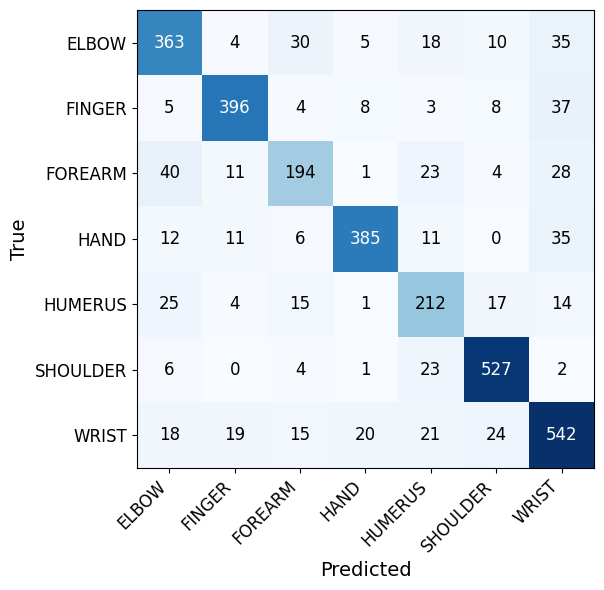

In [25]:

_ = eval_ref_config(64)

/home/eun/miniforge3/envs/mura/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


/home/eun/miniforge3/envs/mura/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/home/eun/miniforge3/envs/mura/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


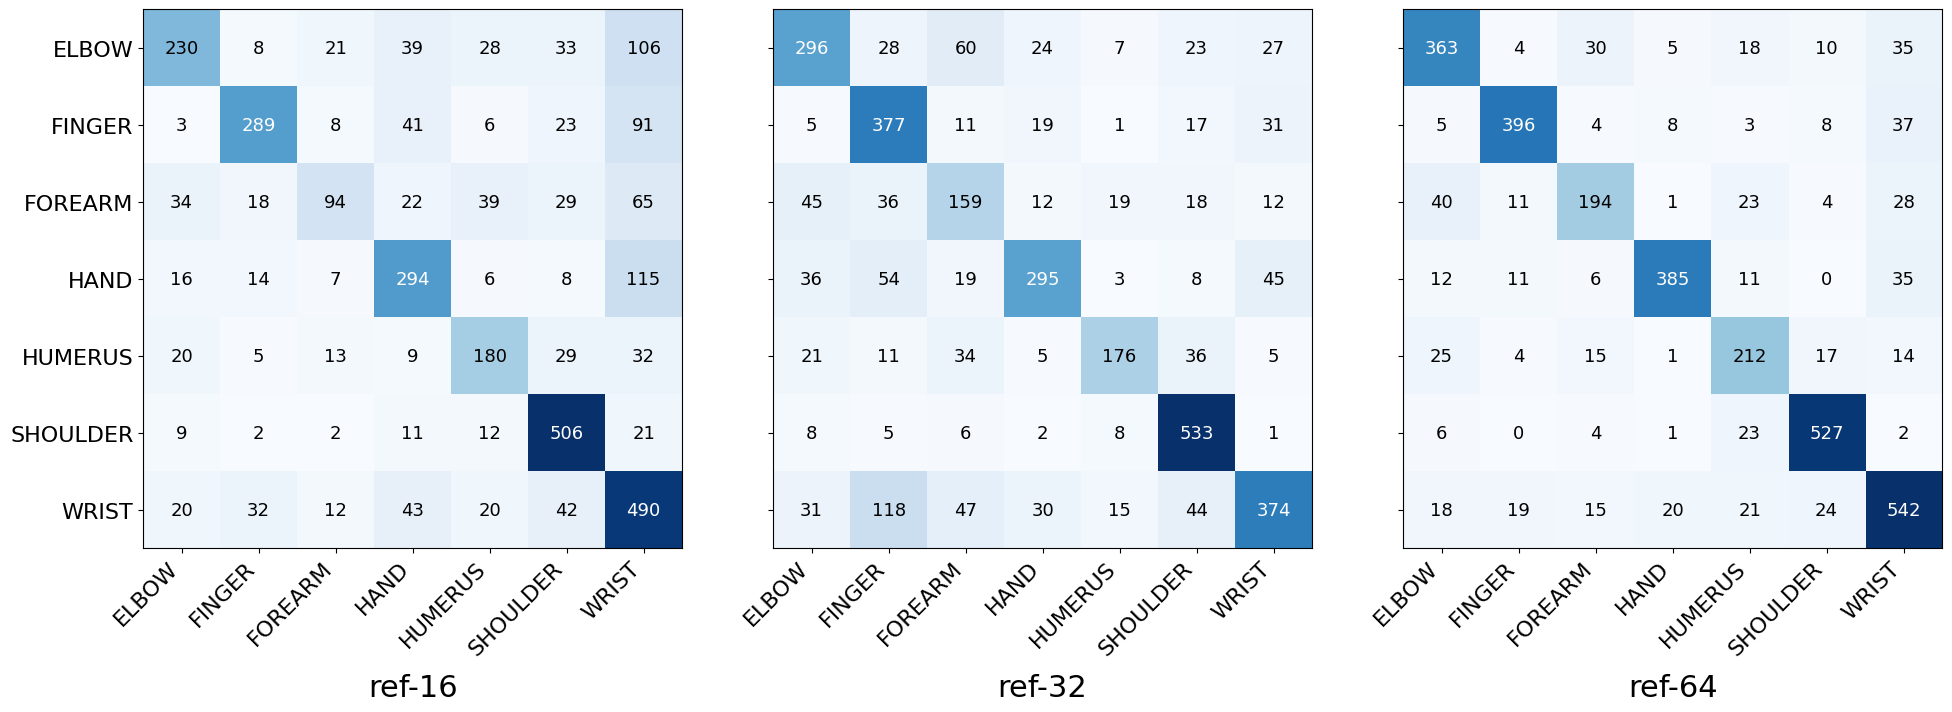

In [14]:
# ── ref-16 / ref-32 / ref-64 confusion matrix 3-panel ──────────────────────
def _get_cm(n_ref):
    mp = f"./mura_xor_slice_{n_ref}ref.pth"
    _, va_ld = _make_loaders(n_ref, batch=128)
    m = XorSliceResNet(len(CLASSES), n_ref=n_ref).to(device)
    m.load_state_dict(torch.load(mp, map_location=device, weights_only=True))
    m.eval()
    preds, trues = [], []
    with torch.no_grad():
        for imgs, sc, lbl in va_ld:
            preds.extend(m(imgs.to(device), sc.to(device)).argmax(1).cpu().numpy())
            trues.extend(lbl.numpy())
    return confusion_matrix(np.array(trues), np.array(preds))

cm16 = _get_cm(16)
cm32 = _get_cm(32)
cm64 = _get_cm(64)

configs = [(16, cm16), (32, cm32), (64, cm64)]

fig, axes = plt.subplots(1, 3, figsize=(24, 7), sharey=True)
fig.subplots_adjust(wspace=0.05)

for idx, (ax, (n_ref, cm)) in enumerate(zip(axes, configs)):
    ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(7)); ax.set_yticks(range(7))
    ax.set_xticklabels(CLASSES, fontsize=16, rotation=45, ha='right')
    if idx == 0:
        ax.set_yticklabels(CLASSES, fontsize=16)
    ax.set_xlabel(f'ref-{n_ref}', fontsize=22, labelpad=10)
    thresh = cm.max() / 2
    for i in range(7):
        for j in range(7):
            ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=13,
                    color='white' if cm[i, j] > thresh else 'black')

plt.savefig("mura_xor_cm_3panel.pdf", format='pdf', bbox_inches='tight')
plt.savefig("mura_xor_cm_3panel.png", dpi=200, bbox_inches='tight')
plt.show()

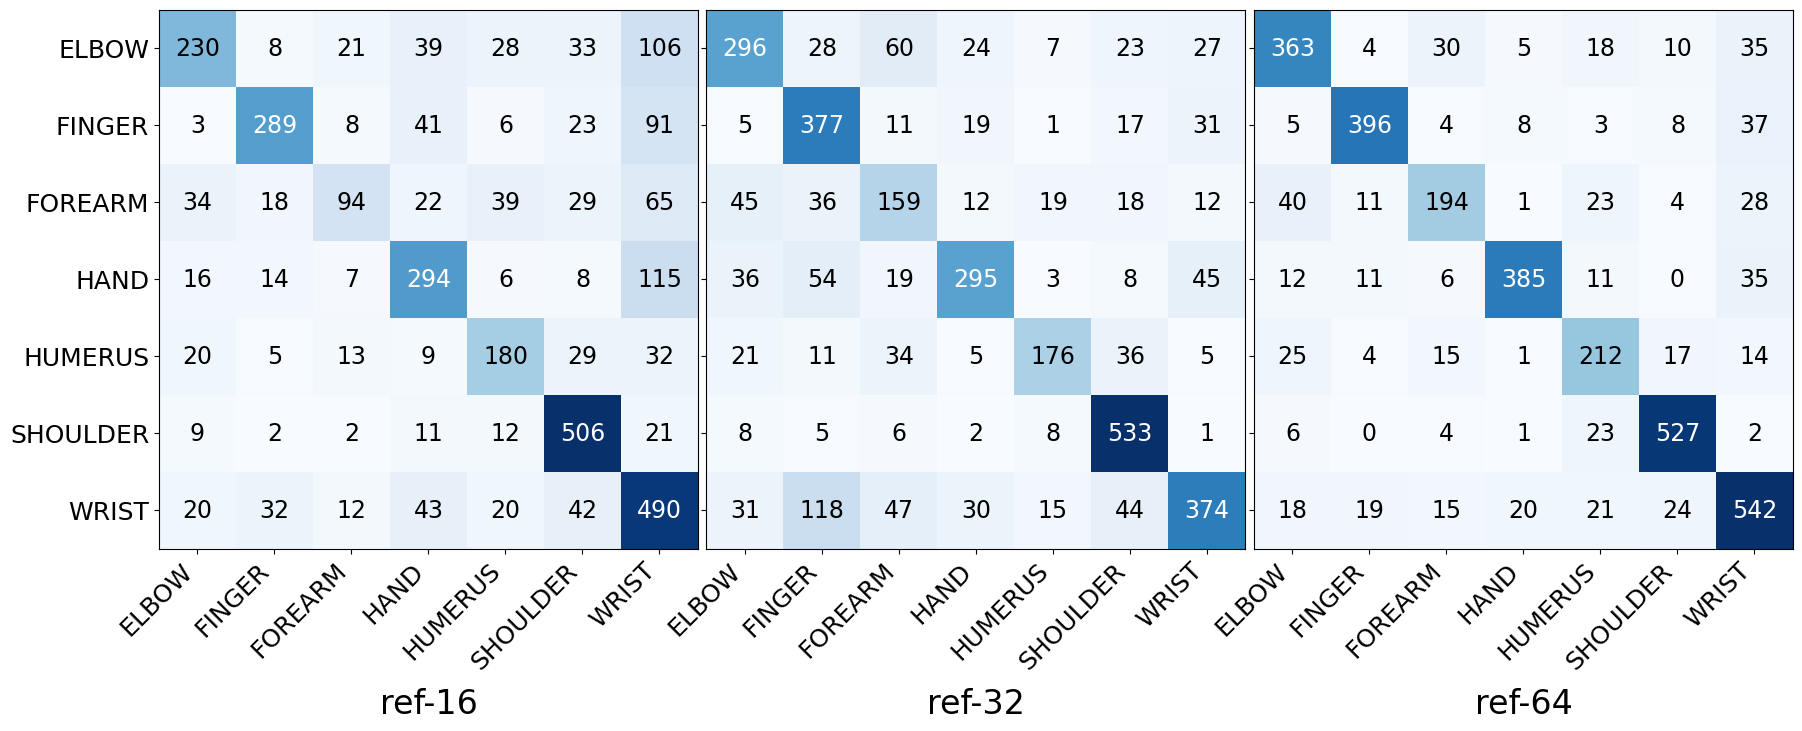

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(21.2, 7), sharey=True)
fig.subplots_adjust(wspace=-0.001)

for idx, (ax, (n_ref, cm)) in enumerate(zip(axes, configs)):
    ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(7)); ax.set_yticks(range(7))
    ax.set_xticklabels(CLASSES, fontsize=18, rotation=45, ha='right')
    if idx == 0:
        ax.set_yticklabels(CLASSES, fontsize=18)
    ax.set_xlabel(f'ref-{n_ref}', fontsize=24, labelpad=10)
    thresh = cm.max() / 2
    for i in range(7):
        for j in range(7):
            ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=17,
                    color='white' if cm[i, j] > thresh else 'black')

plt.savefig("mura_xor_cm_3panel.pdf", format='pdf', bbox_inches='tight')
plt.savefig("mura_xor_cm_3panel.png", dpi=200, bbox_inches='tight')
plt.show()

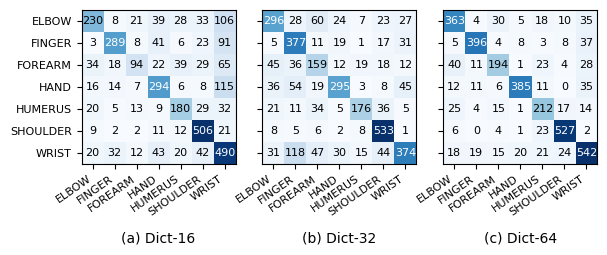

In [18]:
import os, glob, torch, numpy as np
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import StepLR
from PIL import Image
import torchvision.transforms.functional as TF
from collections import Counter
from concurrent.futures import ThreadPoolExecutor, as_completed
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import time
fig, axes = plt.subplots(1, 3, figsize=(7, 2), sharey=True)
fig.subplots_adjust(wspace=0.001)

panel_labels = ['(a)', '(b)', '(c)']

for idx, (ax, (n_ref, cm), label) in enumerate(zip(axes, configs, panel_labels)):
    ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(7)); ax.set_yticks(range(7))
    ax.set_xticklabels(CLASSES, fontsize=8, rotation=35, ha='right')
    if idx == 0:
        ax.set_yticklabels(CLASSES, fontsize=8)
    
    ax.set_xlabel(f'{label} Dict-{n_ref}', fontsize=10, labelpad=10)
    
    thresh = cm.max() / 2
    for i in range(7):
        for j in range(7):
            ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=8,
                    color='white' if cm[i, j] > thresh else 'black')

plt.savefig("mura_xor_cm_3panel.pdf", format='pdf', bbox_inches='tight')
plt.savefig("mura_xor_cm_3panel.png", dpi=200, bbox_inches='tight')
plt.show()

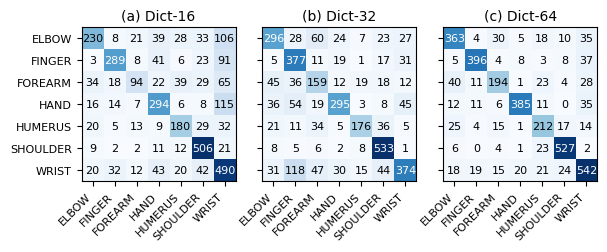

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(7, 2), sharey=True)
fig.subplots_adjust(wspace=0.001)

panel_labels = ['(a)', '(b)', '(c)']

for idx, (ax, (n_ref, cm), label) in enumerate(
    zip(axes, configs, panel_labels)
):
    ax.imshow(cm, cmap='Blues')

    ax.set_xticks(range(7))
    ax.set_yticks(range(7))

    ax.set_xticklabels(
        CLASSES,
        fontsize=8,
        rotation=45,
        ha='right'
    )

    if idx == 0:
        ax.set_yticklabels(CLASSES, fontsize=8)

    # Move panel label above each graph
    ax.set_title(
        f'{label} Dict-{n_ref}',
        fontsize=10,
        pad=5
    )

    thresh = cm.max() / 2

    for i in range(7):
        for j in range(7):
            ax.text(
                j, i, cm[i, j],
                ha='center',
                va='center',
                fontsize=8,
                color='white' if cm[i, j] > thresh else 'black'
            )

plt.savefig(
    "mura_xor_cm_3panel.pdf",
    format='pdf',
    bbox_inches='tight'
)
plt.savefig(
    "mura_xor_cm_3panel.png",
    dpi=200,
    bbox_inches='tight'
)
plt.savefig("mura_xor_cm_3panel_labelup.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [15]:

# ── Top-k accuracy 분석: ref-16 / ref-32 / ref-64 ──────────────────────────
# 재학습 불필요 — softmax 확률 기반 ranked prediction.
def topk_eval(n_ref):
    mp = f"./mura_xor_slice_{n_ref}ref.pth"
    _, va_ld = _make_loaders(n_ref, batch=128)
    m = XorSliceResNet(len(CLASSES), n_ref=n_ref).to(device)
    m.load_state_dict(torch.load(mp, map_location=device, weights_only=True))
    m.eval()
    all_probs, all_trues = [], []
    with torch.no_grad():
        for imgs, sc, lbl in va_ld:
            logits = m(imgs.to(device), sc.to(device))
            all_probs.append(torch.softmax(logits, dim=1).cpu().numpy())
            all_trues.extend(lbl.numpy())
    probs = np.concatenate(all_probs, axis=0)   # (N, 7)
    trues = np.array(all_trues)                  # (N,)
    ranked = probs.argsort(axis=1)[:, ::-1]      # (N, 7) desc
    return probs, trues, ranked

results = {}
for n_ref in [16, 32, 64]:
    probs, trues, ranked = topk_eval(n_ref)
    results[n_ref] = (probs, trues, ranked)

# ── Overall top-k accuracy ───────────────────────────────────────────────────
print(f"{'':10s}", end="")
for k in range(1, 8):
    print(f"  top-{k:d}", end="")
print()

for n_ref in [16, 32, 64]:
    probs, trues, ranked = results[n_ref]
    print(f"ref-{n_ref:>2d}    ", end="")
    for k in range(1, 8):
        hit = np.array([trues[i] in ranked[i, :k] for i in range(len(trues))])
        print(f" {100*hit.mean():5.1f}%", end="")
    print()

# ── Per-class top-k accuracy ────────────────────────────────────────────────
for n_ref in [16, 32, 64]:
    probs, trues, ranked = results[n_ref]
    print(f"\n===== ref-{n_ref} per-class top-k =====")
    print(f"{'class':10s}", end="")
    for k in [1, 2, 3]:
        print(f"  top-{k:d}", end="")
    print(f"  {'n':>5}")
    for ci, cls in enumerate(CLASSES):
        mask = trues == ci
        n = mask.sum()
        print(f"{cls:10s}", end="")
        for k in [1, 2, 3]:
            hit = np.array([trues[i] in ranked[i, :k] for i in range(len(trues)) if mask[i]])
            print(f" {100*hit.mean():5.1f}%", end="")
        print(f"  {n:>5}")

# ── 평균 confidence (정답일 때 vs 오답일 때) ─────────────────────────────────
print(f"\n{'':10s} {'correct_conf':>13s} {'wrong_conf':>13s} {'gap':>8s}")
for n_ref in [16, 32, 64]:
    probs, trues, ranked = results[n_ref]
    correct = ranked[:, 0] == trues
    conf_correct = probs[np.arange(len(trues)), trues][correct].mean()
    conf_wrong   = probs[np.arange(len(trues)), trues][~correct].mean()
    print(f"ref-{n_ref:>2d}     {100*conf_correct:>12.1f}% {100*conf_wrong:>12.1f}% {100*(conf_correct - conf_wrong):>7.1f}pp")


/home/eun/miniforge3/envs/mura/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


            top-1  top-2  top-3  top-4  top-5  top-6  top-7
ref-16      65.2%  78.7%  86.5%  91.6%  94.7%  97.8% 100.0%
ref-32      69.1%  79.5%  85.0%  89.6%  93.9%  97.5% 100.0%
ref-64      81.9%  88.6%  92.2%  95.4%  97.9%  99.2% 100.0%

===== ref-16 per-class top-k =====
class       top-1  top-2  top-3      n
ELBOW       49.5%  60.9%  66.9%    465
FINGER      62.7%  76.4%  86.8%    461
FOREARM     31.2%  57.1%  80.4%    301
HAND        63.9%  88.0%  91.7%    460
HUMERUS     62.5%  77.8%  88.5%    288
SHOULDER    89.9%  93.6%  95.0%    563
WRIST       74.4%  84.1%  91.4%    659

===== ref-32 per-class top-k =====
class       top-1  top-2  top-3      n
ELBOW       63.7%  72.0%  78.7%    465
FINGER      81.8%  88.3%  93.5%    461
FOREARM     52.8%  73.8%  86.4%    301
HAND        64.1%  71.7%  75.9%    460
HUMERUS     61.1%  84.7%  95.8%    288
SHOULDER    94.7%  96.8%  97.9%    563
WRIST       56.8%  69.5%  73.6%    659

===== ref-64 per-class top-k =====
class       top-1  top-2  to

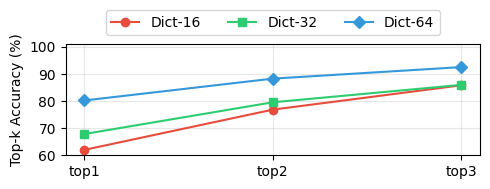

          top-1  top-2  top-3
ref-16    62.0%  76.8%  85.8%
ref-32    67.8%  79.5%  86.0%
ref-64    80.2%  88.3%  92.5%


In [16]:
import os, glob, torch, numpy as np
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import StepLR
from PIL import Image
import torchvision.transforms.functional as TF
from collections import Counter
from concurrent.futures import ThreadPoolExecutor, as_completed
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import time
# ── Top-k accuracy line plot (macro-average: 클래스별 top-k 후 단순 평균) ──────
fig, ax = plt.subplots(figsize=(5, 2))
ks = np.arange(1, 4)   # top-1 ~ top-3만 표시
styles = {16: ('o-', '#e74c3c'), 32: ('s-', '#2ecc71'), 64: ('D-', '#3498db')}

def macro_topk(trues, ranked, k):
    """7개 클래스 각각의 top-k accuracy를 구한 뒤 단순 평균 (unweighted / macro)."""
    per_class = []
    for ci in range(len(CLASSES)):
        mask = trues == ci
        hit  = np.array([trues[i] in ranked[i, :k] for i in range(len(trues)) if mask[i]])
        per_class.append(hit.mean())
    return float(np.mean(per_class))

for n_ref in [16, 32, 64]:
    _, trues, ranked = results[n_ref]
    accs = [macro_topk(trues, ranked, k) for k in ks]
    fmt, color = styles[n_ref]
    ax.plot(ks, [a * 100 for a in accs], fmt, color=color, label=f'Dict-{n_ref}', markersize=6)

ax.set_ylabel('Top-k Accuracy (%)')
ax.set_xticks(ks)
ax.set_xticklabels([f'top{k}' for k in ks])
plt.yticks([60,70,80,90,100])
ax.set_ylim(60, 101)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=3, frameon=True)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig('topk_accuracy.pdf', bbox_inches='tight')
fig.savefig('topk_accuracy.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"{'':8s}" + "".join(f"  top-{k}" for k in ks))
for n_ref in [16, 32, 64]:
    _, trues, ranked = results[n_ref]
    print(f"ref-{n_ref:>2d}  " + "".join(f" {100*macro_topk(trues, ranked, k):5.1f}%" for k in ks))


## XorSliceSENet v2 (64-ref) — inference & v1 비교
`train_64ref_v2.py`로 별도 학습된 SE-ResNet 기반 모델(`mura_xor_slice_64ref_v2.pth`)을 불러와 추론하고, 기존 v1 `XorSliceResNet` (64-ref) 결과와 confusion matrix / per-class accuracy를 비교한다.

- v1 대비 변경점: SEResBlock(채널 attention) + global-stats branch(ref별 매칭 비율) + 채널 확장(64→128→256→512) + warmup cosine LR
- 재학습 불필요 — `xor_cache_64/` 캐시와 저장된 두 checkpoint만 사용

In [14]:
# ── XorSliceSENet (v2) 정의 — train_64ref_v2.py 와 동일 아키텍처 ──────────────
class SELayer(nn.Module):
    """Channel squeeze-and-excitation (along channel dim = ref pages)."""
    def __init__(self, ch, reduction=16):
        super().__init__()
        mid = max(ch // reduction, 4)
        self.fc = nn.Sequential(
            nn.Linear(ch, mid, bias=False), nn.ReLU(inplace=True),
            nn.Linear(mid, ch, bias=False), nn.Sigmoid(),
        )

    def forward(self, x):
        # x: (B, C, H, W)
        scale = self.fc(x.mean(dim=(2, 3)))       # (B, C)
        return x * scale[:, :, None, None]


class SEResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, se_reduction=16):
        super().__init__()
        self.c1   = nn.Conv2d(in_ch,  out_ch, 3, stride=stride, padding=1, bias=False)
        self.b1   = nn.BatchNorm2d(out_ch)
        self.c2   = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.b2   = nn.BatchNorm2d(out_ch)
        self.se   = SELayer(out_ch, se_reduction)
        self.down = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
            nn.BatchNorm2d(out_ch),
        ) if (stride != 1 or in_ch != out_ch) else nn.Identity()

    def forward(self, x):
        h = F.relu(self.b1(self.c1(x)), inplace=True)
        h = self.se(self.b2(self.c2(h)))
        return F.relu(h + self.down(x), inplace=True)


class XorSliceSENet(nn.Module):
    """
    두 브랜치:
      (A) Spatial branch: (B, N_REF, 224, 56) → SE-ResNet → GAP → (B, 512)
      (B) Global stats branch: per-ref match ratio (B, N_REF) → MLP → (B, 128)
    Merge + aspect ratio → (B, 641) → head → 7 classes
    """
    def __init__(self, num_classes=7, n_ref=64):
        super().__init__()
        # --- Spatial branch ---
        self.stem = nn.Sequential(
            nn.Conv2d(n_ref, 64, kernel_size=(7, 3), stride=(2, 1),
                      padding=(3, 1), bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            SELayer(64),
        )
        self.pool1  = nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1))
        self.layer1 = SEResBlock(64,  128, stride=1)
        self.layer2 = SEResBlock(128, 256, stride=2)
        self.layer3 = SEResBlock(256, 512, stride=2)
        self.layer4 = SEResBlock(512, 512, stride=2)
        self.gap    = nn.AdaptiveAvgPool2d(1)       # → (B, 512)

        # --- Global stats branch ---
        self.stats_head = nn.Sequential(
            nn.Linear(n_ref, 256), nn.BatchNorm1d(256), nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 128), nn.ReLU(inplace=True),
        )                                            # → (B, 128)

        # --- Classifier head ---
        self.head = nn.Sequential(
            nn.Linear(512 + 128 + 1, 512), nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes),
        )

    def forward(self, x, sc):
        stats      = x.mean(dim=(2, 3))             # (B, N_REF)
        stats_feat = self.stats_head(stats)          # (B, 128)

        x = self.pool1(self.stem(x))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        sp_feat = self.gap(x).flatten(1)             # (B, 512)

        return self.head(torch.cat([sp_feat, stats_feat, sc], dim=1))

print("XorSliceSENet (v2) defined")

XorSliceSENet (v2) defined


XorSliceSENet params=10,350,855


/home/eun/miniforge3/envs/mura/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


===== 64-ref v2 (XorSliceSENet) =====
              precision    recall  f1-score   support

       ELBOW       0.69      0.75      0.71       465
      FINGER       0.79      0.87      0.83       461
     FOREARM       0.73      0.60      0.66       301
        HAND       0.90      0.74      0.81       460
     HUMERUS       0.49      0.74      0.59       288
    SHOULDER       0.87      0.89      0.88       563
       WRIST       0.83      0.69      0.75       659

    accuracy                           0.76      3197
   macro avg       0.76      0.75      0.75      3197
weighted avg       0.78      0.76      0.77      3197

Per-class accuracy:
  ELBOW     : 74.6%  (465 samples)
  FINGER    : 87.2%  (461 samples)
  FOREARM   : 60.5%  (301 samples)
  HAND      : 73.7%  (460 samples)
  HUMERUS   : 73.6%  (288 samples)
  SHOULDER  : 89.3%  (563 samples)
  WRIST     : 68.6%  (659 samples)


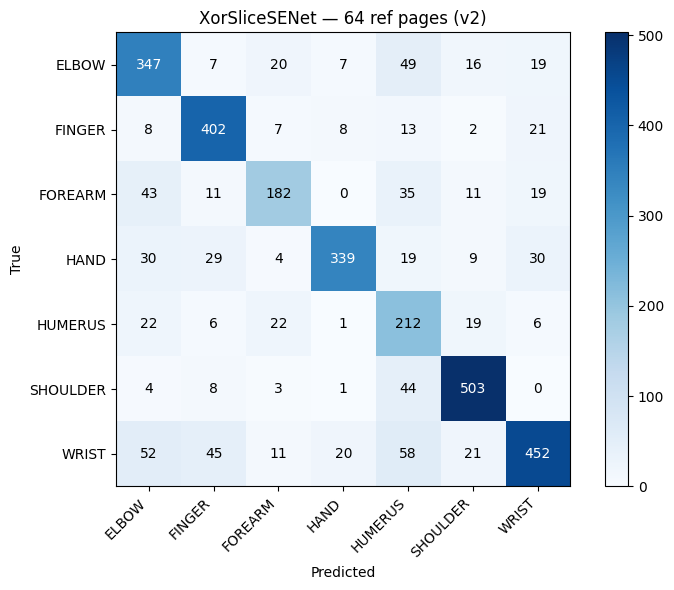

In [15]:
# ── v2 (SENet, 64-ref) 추론 — xor_cache_64 재사용, 재학습 불필요 ──────────────
XOR_64_V2_MODEL_PATH = "./mura_xor_slice_64ref_v2.pth"
if not os.path.exists(XOR_64_V2_MODEL_PATH):
    raise FileNotFoundError(
        f"{XOR_64_V2_MODEL_PATH} not found — train_64ref_v2.py 로 먼저 학습하거나 pth 파일을 복사하세요"
    )

_, va_ld_v2 = _make_loaders(64, batch=128)

senet64 = XorSliceSENet(len(CLASSES), n_ref=64).to(device)
n_params_senet = sum(p.numel() for p in senet64.parameters())
print(f"XorSliceSENet params={n_params_senet:,}")
senet64.load_state_dict(torch.load(XOR_64_V2_MODEL_PATH, map_location=device, weights_only=True))
senet64.eval()

preds_v2, trues_v2 = [], []
with torch.no_grad():
    for imgs, sc, lbl in va_ld_v2:
        preds_v2.extend(senet64(imgs.to(device), sc.to(device)).argmax(1).cpu().numpy())
        trues_v2.extend(lbl.numpy())
preds_v2, trues_v2 = np.array(preds_v2), np.array(trues_v2)

print("===== 64-ref v2 (XorSliceSENet) =====")
print(classification_report(trues_v2, preds_v2, target_names=CLASSES))
print("Per-class accuracy:")
for i, c in enumerate(CLASSES):
    m = trues_v2 == i
    print(f"  {c:10s}: {(preds_v2[m]==i).mean()*100:.1f}%  ({m.sum()} samples)")

cm_v2 = confusion_matrix(trues_v2, preds_v2)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_v2, cmap='Blues')
fig.colorbar(im, ax=ax)
ax.set(xticks=range(7), yticks=range(7), xticklabels=CLASSES, yticklabels=CLASSES,
       ylabel='True', xlabel='Predicted',
       title='XorSliceSENet — 64 ref pages (v2)')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
thresh = cm_v2.max() / 2
for i in range(7):
    for j in range(7):
        ax.text(j, i, cm_v2[i, j], ha='center', va='center',
                color='white' if cm_v2[i, j] > thresh else 'black')
plt.tight_layout()
plt.savefig("mura_xor64_v2_confusion_matrix.pdf", format='pdf', bbox_inches='tight')
plt.savefig("mura_xor64_v2_confusion_matrix.png", format='png', dpi=300, bbox_inches='tight')
plt.show()

/home/eun/miniforge3/envs/mura/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


===== 64-ref =====
              precision    recall  f1-score   support

       ELBOW       0.77      0.78      0.78       465
      FINGER       0.89      0.86      0.87       461
     FOREARM       0.72      0.64      0.68       301
        HAND       0.91      0.84      0.87       460
     HUMERUS       0.68      0.74      0.71       288
    SHOULDER       0.89      0.94      0.91       563
       WRIST       0.78      0.82      0.80       659

    accuracy                           0.82      3197
   macro avg       0.81      0.80      0.80      3197
weighted avg       0.82      0.82      0.82      3197

Per-class accuracy:
  ELBOW     : 78.1%  (465 samples)
  FINGER    : 85.9%  (461 samples)
  FOREARM   : 64.5%  (301 samples)
  HAND      : 83.7%  (460 samples)
  HUMERUS   : 73.6%  (288 samples)
  SHOULDER  : 93.6%  (563 samples)
  WRIST     : 82.2%  (659 samples)


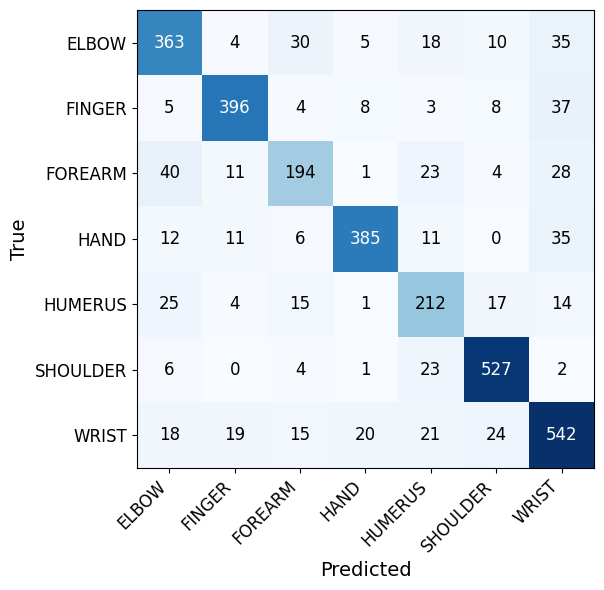

64-ref v1 (XorSliceResNet) overall accuracy: 81.9%
64-ref v2 (XorSliceSENet)  overall accuracy: 76.2%
delta (v2 - v1): -5.7pp


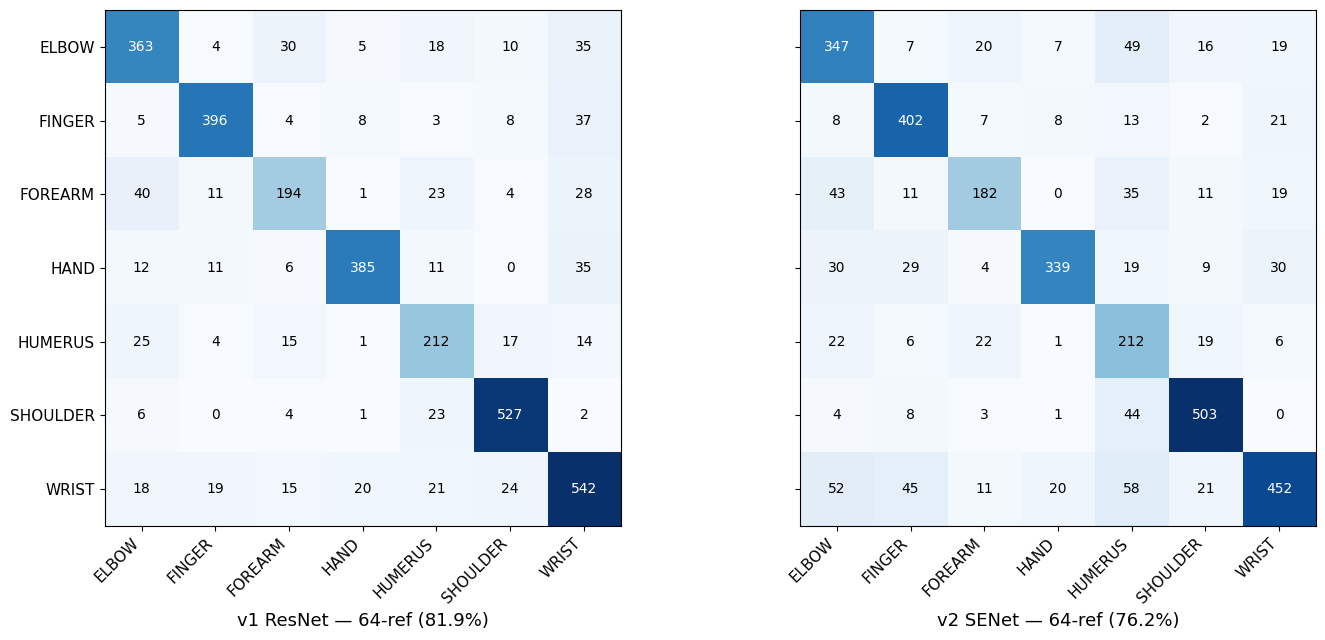

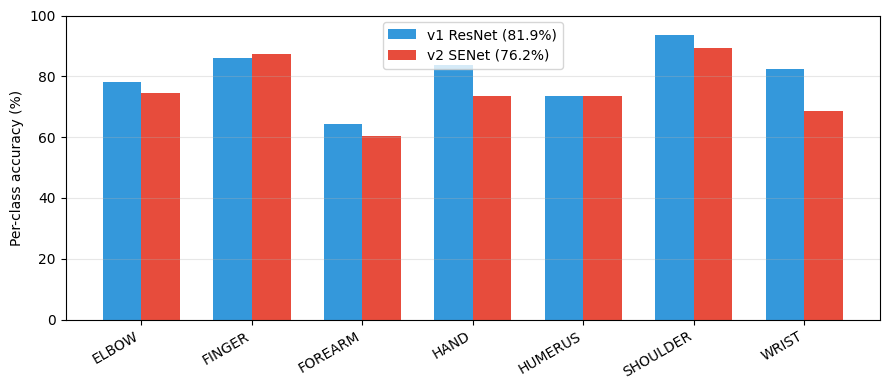

In [16]:
# ── v1 (XorSliceResNet) vs v2 (XorSliceSENet) — 64-ref 비교 시각화 ────────────
preds_v1, trues_v1 = eval_ref_config(64)   # 저장된 best 모델 재로드 후 추론만 수행 (재학습 없음)

acc_v1 = (preds_v1 == trues_v1).mean() * 100
acc_v2 = (preds_v2 == trues_v2).mean() * 100
print(f"64-ref v1 (XorSliceResNet) overall accuracy: {acc_v1:.1f}%")
print(f"64-ref v2 (XorSliceSENet)  overall accuracy: {acc_v2:.1f}%")
print(f"delta (v2 - v1): {acc_v2 - acc_v1:+.1f}pp")

cm_v1 = confusion_matrix(trues_v1, preds_v1)

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), sharey=True)
for ax, cm, label, acc in zip(axes, [cm_v1, cm_v2], ['v1 ResNet', 'v2 SENet'], [acc_v1, acc_v2]):
    ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(7)); ax.set_yticks(range(7))
    ax.set_xticklabels(CLASSES, rotation=45, ha='right', fontsize=11)
    ax.set_yticklabels(CLASSES, fontsize=11)
    ax.set_xlabel(f'{label} — 64-ref ({acc:.1f}%)', fontsize=13)
    thresh = cm.max() / 2
    for i in range(7):
        for j in range(7):
            ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=10,
                    color='white' if cm[i, j] > thresh else 'black')
plt.tight_layout()
plt.savefig("mura_xor64_v1_vs_v2_cm.pdf", format='pdf', bbox_inches='tight')
plt.savefig("mura_xor64_v1_vs_v2_cm.png", format='png', dpi=200, bbox_inches='tight')
plt.show()

# ── per-class accuracy bar chart ─────────────────────────────────────────────
x = np.arange(len(CLASSES))
w = 0.35
acc_v1_pc = [(preds_v1[trues_v1 == i] == i).mean() * 100 for i in range(len(CLASSES))]
acc_v2_pc = [(preds_v2[trues_v2 == i] == i).mean() * 100 for i in range(len(CLASSES))]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w/2, acc_v1_pc, w, label=f'v1 ResNet ({acc_v1:.1f}%)', color='#3498db')
ax.bar(x + w/2, acc_v2_pc, w, label=f'v2 SENet ({acc_v2:.1f}%)', color='#e74c3c')
ax.set_xticks(x); ax.set_xticklabels(CLASSES, rotation=30, ha='right')
ax.set_ylabel('Per-class accuracy (%)')
ax.set_ylim(0, 100)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("mura_xor64_v1_vs_v2_perclass.pdf", format='pdf', bbox_inches='tight')
plt.savefig("mura_xor64_v1_vs_v2_perclass.png", format='png', dpi=200, bbox_inches='tight')
plt.show()